In [12]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

In [13]:
RANDOM_STATE = 42

In [14]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

print(train.isna().sum())
print(test.isna().sum())

id        0
ASIN      0
text      1
title     3
rating    0
dtype: int64
id       0
ASIN     0
text     1
title    1
dtype: int64


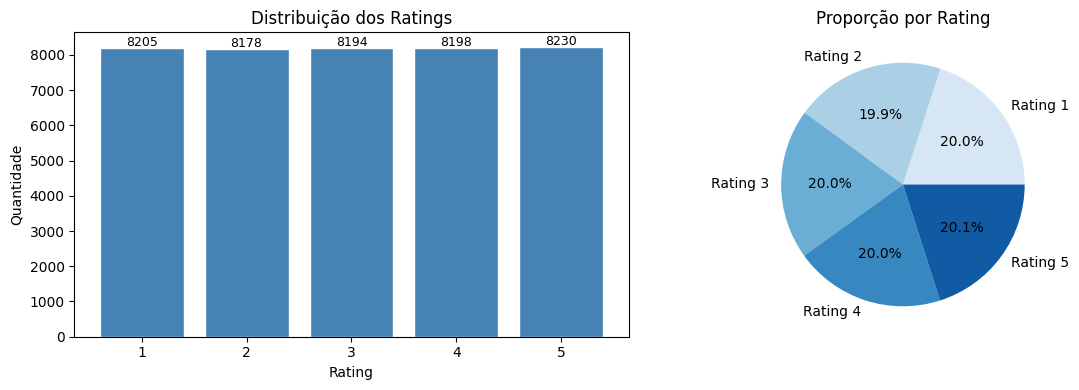

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rating_counts = train["rating"].value_counts().sort_index()
axes[0].bar(
    rating_counts.index, rating_counts.values, color="steelblue", edgecolor="white"
)
axes[0].set_title("Distribuição dos Ratings")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Quantidade")
for i, v in enumerate(rating_counts.values):
    axes[0].text(i + 1, v + 50, str(v), ha="center", fontsize=9)

pct = rating_counts / rating_counts.sum() * 100
axes[1].pie(
    pct.values,
    labels=[f"Rating {i}" for i in pct.index],
    autopct="%1.1f%%",
    colors=sns.color_palette("Blues", 5),
)
axes[1].set_title("Proporção por Rating")

plt.tight_layout()
plt.savefig("figures/distribuicao_rating.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"[^a-záéíóúãõâêîôûàç\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def build_content(df: pd.DataFrame) -> pd.Series:
    """Concatena title (peso duplo) + text após limpeza."""
    title_clean = df["title"].fillna("").apply(clean_text)
    text_clean = df["text"].fillna("").apply(clean_text)
    return title_clean + " " + title_clean + " " + text_clean


train["content"] = build_content(train)
test["content"] = build_content(test)

print("Texto original:")
print(train["text"].iloc[0])
print()
print("Após limpeza:")
print(train["content"].iloc[0])

Texto original:
Por incrível que pareça, para uma bebida destilada, de alta concentração alcoólica, ela tem um sabor bastante suave. Realmente diferenciada se comparada a uma Absolut, p.e. Valeria muito a pena se não fosse tão cara.

Após limpeza:
vodka diferenciada vodka diferenciada por incrível que pareça para uma bebida destilada de alta concentração alcoólica ela tem um sabor bastante suave realmente diferenciada se comparada a uma absolut p e valeria muito a pena se não fosse tão cara


### Bag of Words (BoW)

**Parâmetros:**
- `ngram_range=(1,2)`: captura expressões compostas (*"não funciona"*, *"muito bom"*)
- `max_features=80_000`: controla dimensionalidade
- `min_df=100`: descarta palavras raras
- `stop_words`: remove palavras sem "valor"


In [17]:
PT_STOPWORDS = {
    "a",
    "ao",
    "aos",
    "aquela",
    "aquelas",
    "aquele",
    "aqueles",
    "aquilo",
    "as",
    "ate",
    "com",
    "como",
    "da",
    "das",
    "de",
    "dela",
    "delas",
    "dele",
    "deles",
    "depois",
    "do",
    "dos",
    "e",
    "ela",
    "elas",
    "ele",
    "eles",
    "em",
    "entre",
    "era",
    "essa",
    "essas",
    "esse",
    "esses",
    "esta",
    "estas",
    "este",
    "estes",
    "eu",
    "foi",
    "for",
    "foram",
    "ha",
    "isso",
    "isto",
    "ja",
    "la",
    "lhe",
    "lhes",
    "mais",
    "mas",
    "me",
    "mesmo",
    "meu",
    "meus",
    "minha",
    "minhas",
    "na",
    "nao",
    "nas",
    "nem",
    "no",
    "nos",
    "o",
    "os",
    "ou",
    "para",
    "pela",
    "pelas",
    "pelo",
    "pelos",
    "por",
    "porque",
    "quando",
    "que",
    "quem",
    "se",
    "sem",
    "ser",
    "seu",
    "seus",
    "sua",
    "suas",
    "tam",
    "te",
    "tem",
    "tendo",
    "tenho",
    "ter",
    "toda",
    "todas",
    "todo",
    "todos",
    "tu",
    "tua",
    "tuas",
    "tudo",
    "um",
    "uma",
    "umas",
    "uns",
    "voce",
    "vos",
    "tambem",
    "ainda",
    "so",
    "bem",
    "aqui",
}

BOW_PARAMS = {
    "strip_accents": "unicode",
    "lowercase": True,
    "ngram_range": (1, 2),
    "max_features": 100_000,
    "min_df": 100,
    "stop_words": list(PT_STOPWORDS),
}

X = train["content"]
y = train["rating"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {X_train.shape[0]:}")
print(f"Validação: {X_val.shape[0]}")

Treino: 32804
Validação: 8201


In [29]:
models = {
    "Multinomial NB": Pipeline(
        [
            ("bow", CountVectorizer(**BOW_PARAMS)),
            ("clf", MultinomialNB(alpha=0.1)),
        ],
    ),
    "LinearSVC": Pipeline(
        [
            ("bow", CountVectorizer(**BOW_PARAMS)),
            ("clf", LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE)),
        ],
    ),
    "Logistic Regression": Pipeline(
        [
            ("bow", CountVectorizer(**BOW_PARAMS)),
            (
                "clf",
                LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ],
    ),
}

In [30]:
results = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="macro")
    results[name] = {
        "accuracy": acc,
        "f1_macro": f1,
        "pipeline": pipe,
        "y_pred": y_pred,
    }
    print(f"{name}-> Acurácia: {acc:.4f} | F1 Macro: {f1:.4f}")

Multinomial NB-> Acurácia: 0.4862 | F1 Macro: 0.4811
LinearSVC-> Acurácia: 0.4893 | F1 Macro: 0.4774
Logistic Regression-> Acurácia: 0.4912 | F1 Macro: 0.4848


C:\Users\lucas\AppData\Local\Temp\ipykernel_17708\2233746688.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


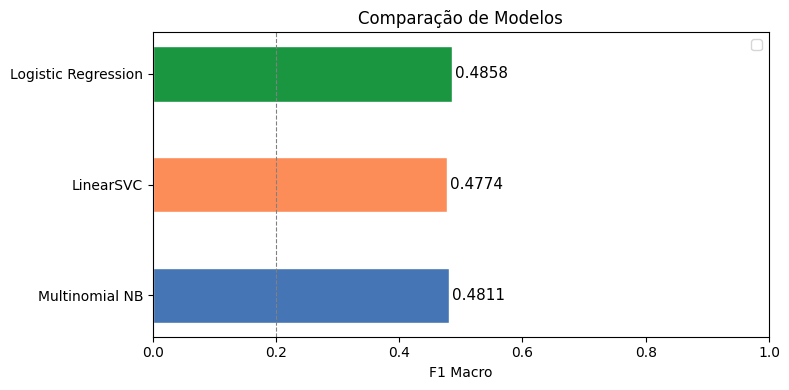

In [26]:
names = list(results.keys())
f1s = [results[n]["f1_macro"] for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    names, f1s, color=["#4575b4", "#fc8d59", "#1a9641"], edgecolor="white", height=0.5
)
ax.set_xlim(0, 1)
ax.set_xlabel("F1 Macro")
ax.set_title("Comparação de Modelos")
for bar, f1 in zip(bars, f1s, strict=False):
    ax.text(
        f1 + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{f1:.4f}",
        va="center",
        fontsize=11,
    )
ax.axvline(
    0.2,
    color="gray",
    linestyle="--",
    linewidth=0.8,
)
ax.legend()
plt.tight_layout()
plt.savefig("figures/comparacao_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
best_name = "Logistic Regression"
best_pipe = results[best_name]["pipeline"]
best_pred = results[best_name]["y_pred"]

print(best_name)
print(f"F1 Macro: {results[best_name]['f1_macro']:.4f}")
print(f"Acurácia: {results[best_name]['accuracy']:.4f}")

Logistic Regression
F1 Macro: 0.4858
Acurácia: 0.4923


Modelo selecionado: Logistic Regression\
Superou Multinomial NB e LinearSVC em F1 Macro neste dataset.

In [22]:
print(
    classification_report(
        y_val, best_pred, target_names=[f"Rating {i}" for i in range(1, 6)],
    ),
)

              precision    recall  f1-score   support

    Rating 1       0.53      0.61      0.57      1641
    Rating 2       0.40      0.35      0.37      1636
    Rating 3       0.40      0.37      0.38      1639
    Rating 4       0.44      0.41      0.42      1639
    Rating 5       0.64      0.72      0.68      1646

    accuracy                           0.49      8201
   macro avg       0.48      0.49      0.49      8201
weighted avg       0.48      0.49      0.49      8201



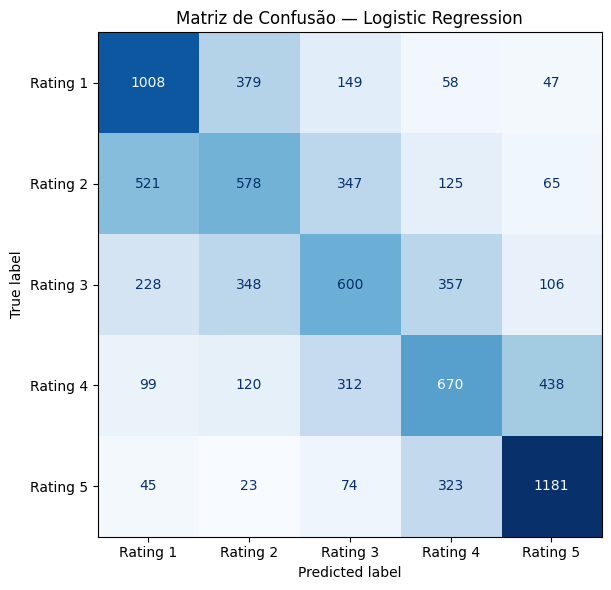

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_val, best_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=[f"Rating {i}" for i in range(1, 6)]
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matriz de Confusão — {best_name}", fontsize=12)
plt.tight_layout()
plt.savefig("figures/matriz_confusao.png", dpi=150, bbox_inches="tight")
plt.show()

Ratings 1 e 5 têm maior precisão pois são naturalmente mais fáceis de serem identificados.\
Ratings 2, 3 e 4 se confundem entre si por serem sentimentos muito próximos.\
Erros tendem a ser entre ratings adjacentes, não opostos.

In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_pipe = Pipeline(
    [("bow", CountVectorizer(**BOW_PARAMS)), ("clf", LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ))],
)

cv_scores = cross_val_score(cv_pipe, X, y, cv=cv, scoring="f1_macro")

print(f"F1 Macro por fold: {[f'{s:.4f}' for s in cv_scores]}")
print(f"Média: {cv_scores.mean():.4f}")
print(f"Desvio padrão: {cv_scores.std():.4f}")

F1 Macro por fold: ['0.4785', '0.4954', '0.4933', '0.4851', '0.4825']
Média: 0.4870
Desvio padrão: 0.0064


Desvio padrão baixo significa que o modelo realmente aprendeu e consegue replicar para diferentes estratificações do dataset

In [32]:
final_pipe = Pipeline(
    [("bow", CountVectorizer(**BOW_PARAMS)), ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    ))],
)
final_pipe.fit(X, y)

test_preds = final_pipe.predict(test["content"])

submission = pd.DataFrame({"id": test["id"], "rating": test_preds})
submission.to_csv("submission.csv", index=False)

print(submission["rating"].value_counts().sort_index())
submission.head()


rating
1    2443
2    1740
3    1794
4    1875
5    2400
Name: count, dtype: int64


,id,rating
0,40261,3
1,46176,2
2,47942,2
3,37329,1
4,13503,5


### Conclusão

| Item | Detalhe |
|---|---|
| Representação | Bag of Words — unigramas + bigramas, 100k features |
| Pré-processamento | Limpeza de texto, stopwords PT-BR, `title` com peso duplo |
| Modelos comparados | Multinomial NB, LinearSVC, Logistic Regression |
| **Modelo final** | **Logistic Regression** (C=5.0, solver=sag) |
| Critério de seleção | F1 Macro |

**Limitações:**
- BoW não captura semântica, negação composta nem ironia.
- Ratings intermediários (2, 3, 4) são naturalmente ambíguos e foram a maior fonte de erro.

**Possíveis melhorias:**
- Char n-grams para capturar morfologia do PT-BR.
- Ajuste de `alpha` via GridSearchCV.
- Ensemble: soft voting entre MNB + LogReg + LinearSVC.
